In [39]:
import vrep 
import sys
import time 
import numpy as np
from tank import *
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt


## W miarę "delikatne" hamowanie

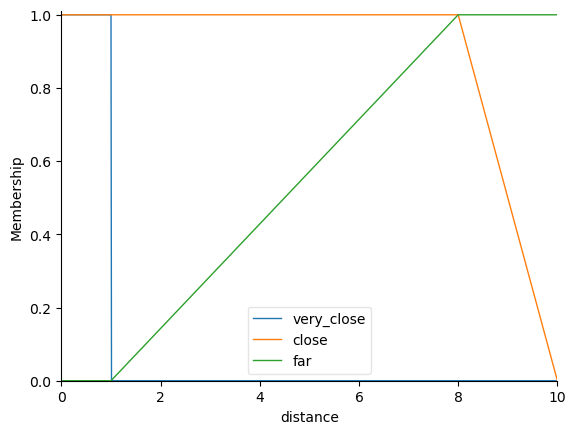

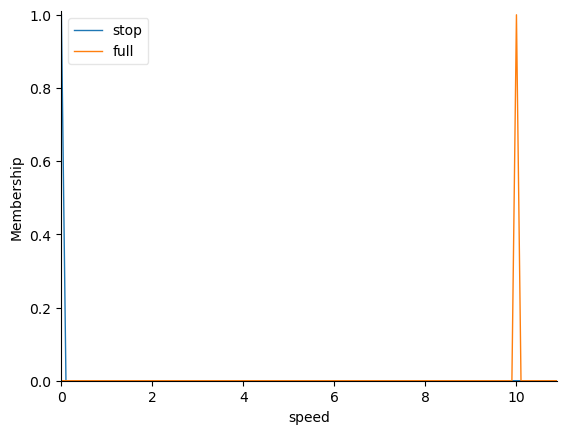

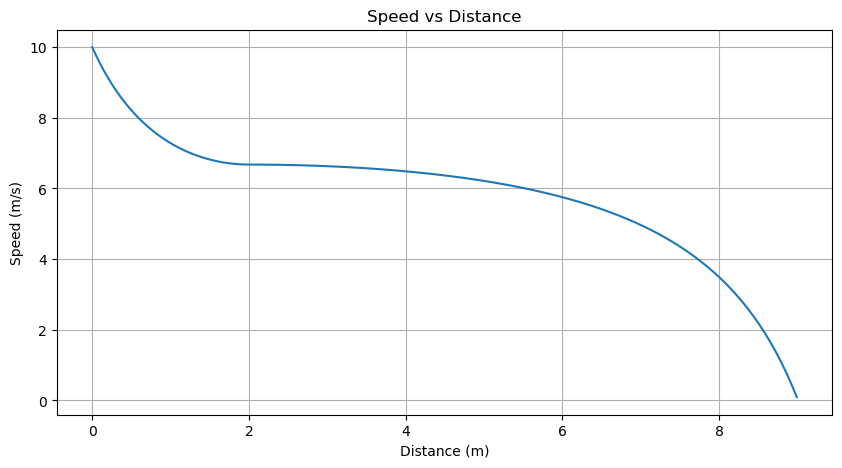

In [164]:
def noAggressive(): 
    distance = ctrl.Antecedent(np.arange(0, 10.01, 0.01), 'distance')
    speed = ctrl.Consequent(np.arange(0, 11, 0.1), 'speed')

    distance['very_close'] = fuzz.trapmf(distance.universe, [0, 0, 1, 1]) 
    distance['close'] = fuzz.trapmf(distance.universe, [0, 0, 8, 10])    
    distance['far'] = fuzz.trapmf(distance.universe, [1, 8, 10, 10])

    speed['stop'] = fuzz.trimf(speed.universe, [0, 0, 0])
    speed['full'] = fuzz.trimf(speed.universe, [10, 10, 10])

    rule1 = ctrl.Rule(distance['very_close'], speed['stop'])
    rule2 = ctrl.Rule(distance['close'], speed['stop'])
    rule3 = ctrl.Rule(distance['far'], speed['full']) 

    tank_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
    tank_sim = ctrl.ControlSystemSimulation(tank_ctrl)

    distance.view()
    speed.view()

    return tank_sim


controller = noAggressive()

speed_list = []
distance_list = []
for i in range(1000, 100, -1):
    controller.input['distance'] = float(i/100) 
    controller.compute()
    vel = controller.output['speed']
    speed_list.append(vel)
    distance_list.append(float((1000 - i)/100) )

plt.figure(figsize=(10, 5))
plt.plot(distance_list, speed_list)
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.title('Speed vs Distance')
plt.grid()
plt.show()

## Ostre hamowanie

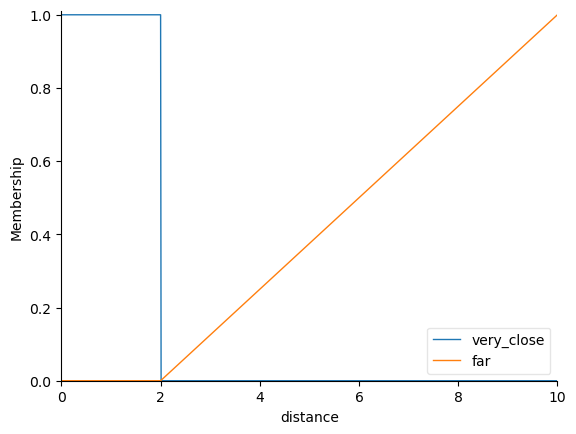

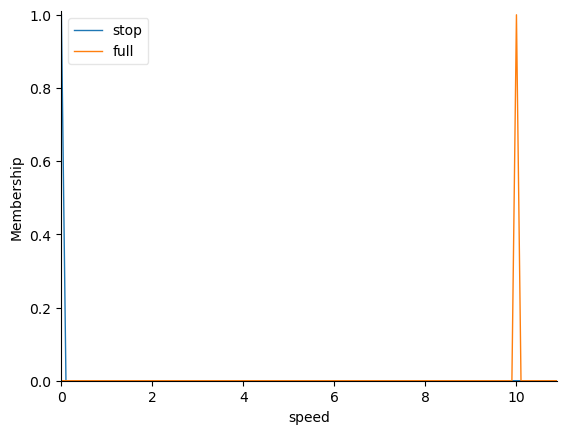

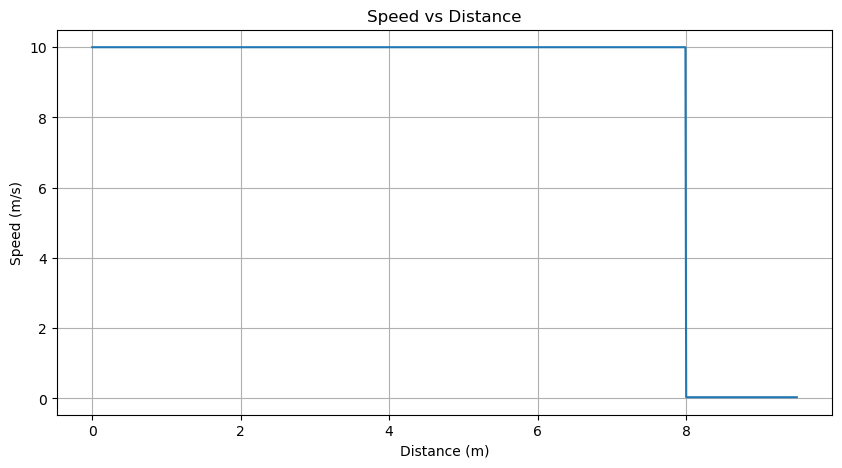

In [154]:
def veeryAggressive(): 
    distance = ctrl.Antecedent(np.arange(0, 10.01, 0.01), 'distance')
    speed = ctrl.Consequent(np.arange(0, 11, 0.1), 'speed')

    distance['very_close'] = fuzz.trapmf(distance.universe, [0, 0, 2, 2]) 
    distance['far'] = fuzz.trapmf(distance.universe, [2, 10, 10, 10])

    speed['stop'] = fuzz.trimf(speed.universe, [0, 0, 0])
    speed['full'] = fuzz.trimf(speed.universe, [10, 10, 10])

    rule1 = ctrl.Rule(distance['very_close'], speed['stop'])
    rule2 = ctrl.Rule(distance['far'], speed['full']) 

    tank_ctrl = ctrl.ControlSystem([rule1, rule2])
    tank_sim = ctrl.ControlSystemSimulation(tank_ctrl)

    distance.view()
    speed.view()

    return tank_sim


controller = noAggressive()

speed_list = []
distance_list = []
for i in range(1000, 50, -1):
    controller.input['distance'] = float(i/100) 
    controller.compute()
    vel = controller.output['speed']
    speed_list.append(vel)
    distance_list.append(float((1000 - i)/100) )

plt.figure(figsize=(10, 5))
plt.plot(distance_list, speed_list)
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.title('Speed vs Distance')
plt.grid()
plt.show()

Connected to remote API server


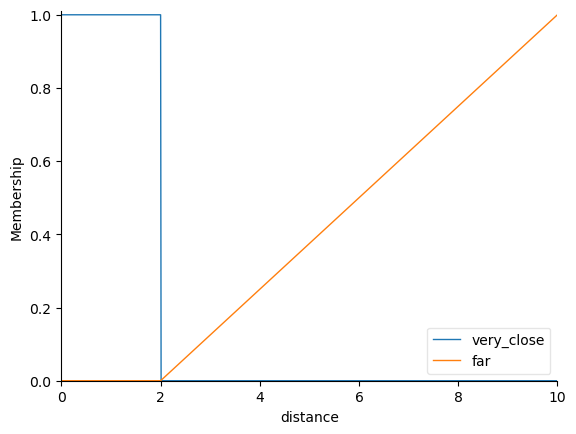

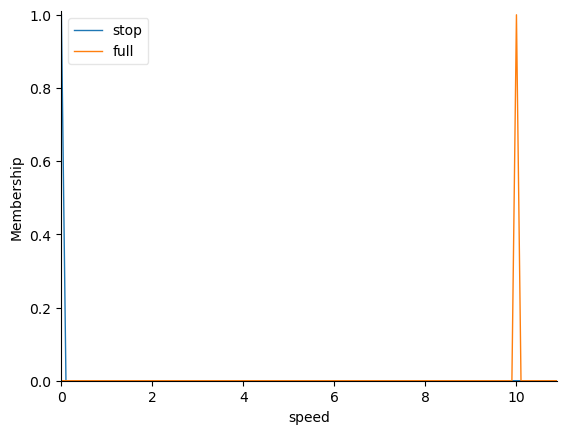

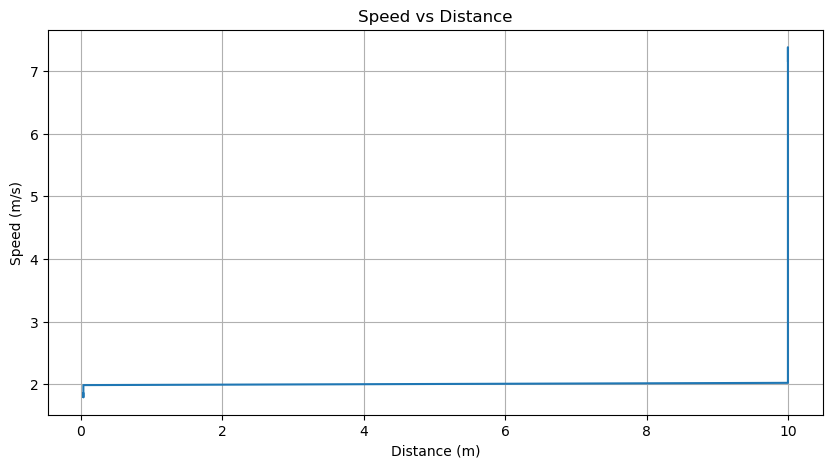

1

In [156]:
vrep.simxFinish(-1) # closes all opened connections, in case any prevoius wasnt finished
clientID=vrep.simxStart('127.0.0.1',19999,True,True,5000,5) # start a connection

if clientID!=-1:
    print ("Connected to remote API server")
else:
    print("Not connected to remote API server")
    sys.exit("Could not connect")

#create instance of Tank
tank=Tank(clientID)

# get handle to proximity sensor
err_code,ps_handle = vrep.simxGetObjectHandle(clientID,"Proximity_sensor", vrep.simx_opmode_blocking)

# controller = noAggressive()
controller = veeryAggressive()

speed_list = []
distance_list = []
t = time.time()
while (time.time()-t)<40:
    err_code, detectionState, detectedPoint, detectedObjectHandle, detectedSurfaceNormalVector = vrep.simxReadProximitySensor(
        clientID, ps_handle, vrep.simx_opmode_streaming)
    if detectionState:
        dist = np.linalg.norm(detectedPoint).astype(np.float32)
        controller.input['distance'] = dist
        controller.compute()
        vel = controller.output['speed']
        speed_list.append(vel)
        distance_list.append(dist)
        tank.forward(velocity=vel)
        # print(f"Distance: {dist:.2f} m, speed: {vel:.2f}")
    else:
        tank.forward(velocity=10)
        # print("No obstacle detected, full speed")

plt.figure(figsize=(10, 5))
plt.plot(speed_list, distance_list)
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.title('Speed vs Distance')
plt.grid()
plt.show()

vrep.simxStopSimulation(clientID,vrep.simx_opmode_oneshot) # stop the simulation in vrep